# Possums!

## Inspiration

Get your feet wet with regression techniques here on Kaggle by using this dataset. Perfect for beginners since the OpenIntro Statistics book does a good explanation in Chapter 8.

* Can we use total length to predict a possum's head length?
* Which possum body dimensions are most correlated with age and sex?
* Can we classify a possum's sex by its body dimensions and location?
* Can we predict a possum's trapping location from its body dimensions?


## Initial Examination and Cleaning

First, import dataset from Kaggle

In [250]:
import kagglehub
from kagglehub import KaggleDatasetAdapter
import pandas as pd
import matplotlib.pyplot as plt

In [251]:
#plt.style.use('ggplot')

In [252]:
df: pd.DataFrame = kagglehub.dataset_load(
    KaggleDatasetAdapter.PANDAS,
    "abrambeyer/openintro-possum",
    "possum.csv"
)

### Initial Data Examination

In [253]:
print("Initial data examination")
print("------------------------")

print("Head:")
print(df.head())

print()
print("Total cases =", df.shape[0])

print()
print("Data types:")
print(df.dtypes)

Initial data examination
------------------------
Head:
   case  site  Pop sex  age  hdlngth  skullw  totlngth  taill  footlgth  \
0     1     1  Vic   m  8.0     94.1    60.4      89.0   36.0      74.5   
1     2     1  Vic   f  6.0     92.5    57.6      91.5   36.5      72.5   
2     3     1  Vic   f  6.0     94.0    60.0      95.5   39.0      75.4   
3     4     1  Vic   f  6.0     93.2    57.1      92.0   38.0      76.1   
4     5     1  Vic   f  2.0     91.5    56.3      85.5   36.0      71.0   

   earconch   eye  chest  belly  
0      54.5  15.2   28.0   36.0  
1      51.2  16.0   28.5   33.0  
2      51.9  15.5   30.0   34.0  
3      52.2  15.2   28.0   34.0  
4      53.2  15.1   28.5   33.0  

Total cases = 104

Data types:
case          int64
site          int64
Pop          object
sex          object
age         float64
hdlngth     float64
skullw      float64
totlngth    float64
taill       float64
footlgth    float64
earconch    float64
eye         float64
chest       float

### Range of Features

Range of features
-----------------
Population (note 'other'='New South Wales'|'Queensland'): ['Vic' 'other']
Sex: ['m' 'f']


<Axes: >

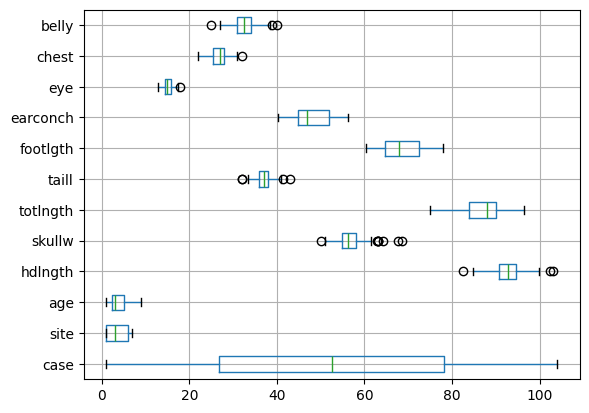

In [254]:
print("Range of features")
print("-----------------")

print("Population (note 'other'='New South Wales'|'Queensland'):", df['Pop'].unique())
print("Sex:", df['sex'].unique())

# matplotlib.pyplot.boxplot deprecates vert
# but it yells at me when I use orientation='horizontal'
df.boxplot(vert=False)

### Null Values

In [255]:
print("Null/NA values")
print("--------------")
na = df.isna()
print("Null values by feature:")
print(na.sum())

print()
print("Total null values =", na.sum().sum())

na_rows = na.any(axis='columns')
print("Total cases with null values =", na_rows.sum())

Null/NA values
--------------
Null values by feature:
case        0
site        0
Pop         0
sex         0
age         2
hdlngth     0
skullw      0
totlngth    0
taill       0
footlgth    1
earconch    0
eye         0
chest       0
belly       0
dtype: int64

Total null values = 3
Total cases with null values = 3


### Cleaning

Since we have only 3/104 (= 2.89%) cases with null values, we choose to simply remove them.

In [256]:
df = df.dropna()

## Exploratory Data Analysis (EDA)


In [257]:
import seaborn as sns
import numpy as np

### Age Distribution

Around 2-5 years old, mostly 3 years old.

Age Distribution
-----------------
count    101.00
mean       3.82
std        1.92
min        1.00
25%        2.00
50%        3.00
75%        5.00
max        9.00
Name: age, dtype: float64


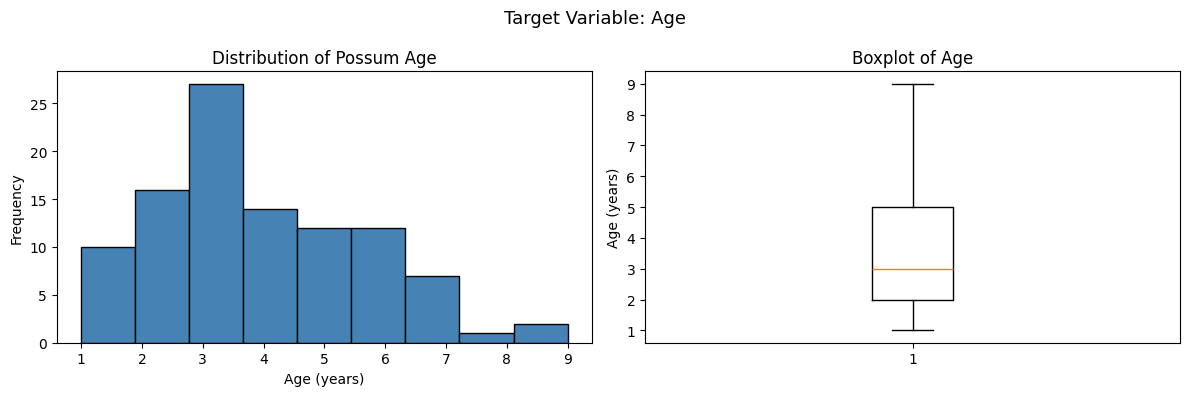

In [258]:
print("Age Distribution")
print("-----------------")
print(df["age"].describe().round(2))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(df["age"].dropna(), bins=9, edgecolor="black", color="steelblue")
axes[0].set_title("Distribution of Possum Age")
axes[0].set_xlabel("Age (years)")
axes[0].set_ylabel("Frequency")

# Fix: drop NaNs and convert to list
axes[1].boxplot(df["age"].dropna().tolist())
axes[1].set_title("Boxplot of Age")
axes[1].set_ylabel("Age (years)")

plt.suptitle("Target Variable: Age", fontsize=13)
plt.tight_layout()
plt.show()

### Age by Categorical Variables (Sex & Population)

Age by Categorical Variables (Sex & Population)
-----------------


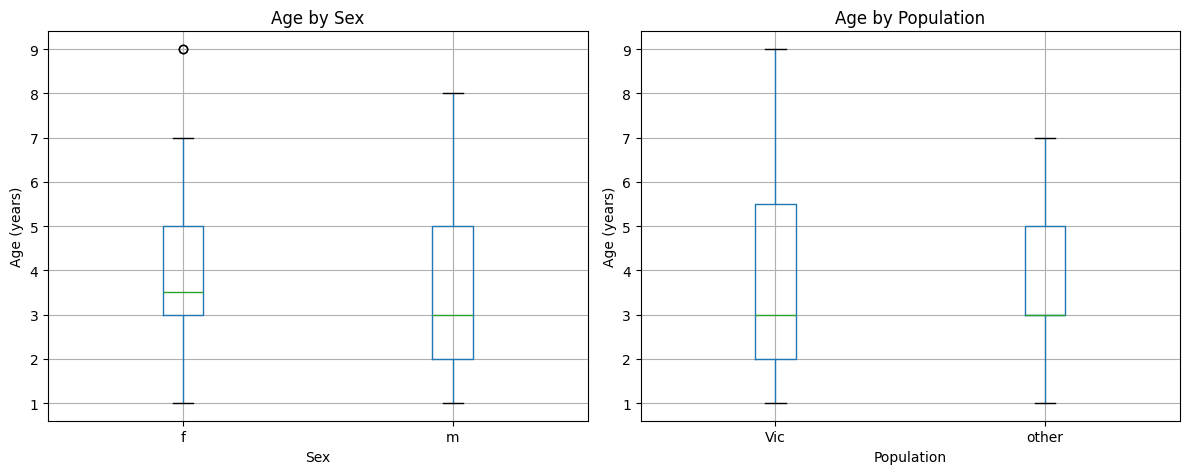

Mean age by sex:
sex
f    3.95
m    3.73
Name: age, dtype: float64

Mean age by population:
Pop
Vic      4.00
other    3.69
Name: age, dtype: float64


In [259]:
print("Age by Categorical Variables (Sex & Population)")
print("-----------------")

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

df.boxplot(column="age", by="sex", ax=axes[0])
axes[0].set_title("Age by Sex")
axes[0].set_xlabel("Sex")
axes[0].set_ylabel("Age (years)")

df.boxplot(column="age", by="Pop", ax=axes[1])
axes[1].set_title("Age by Population")
axes[1].set_xlabel("Population")
axes[1].set_ylabel("Age (years)")

plt.suptitle("")  # removes default suptitle
plt.tight_layout()
plt.show()

print("Mean age by sex:")
print(df.groupby("sex")["age"].mean().round(2))
print("\nMean age by population:")
print(df.groupby("Pop")["age"].mean().round(2))

### Numeric Correlation Heatmap

Correlation Heatmap (Numeric Features Only)
-----------------


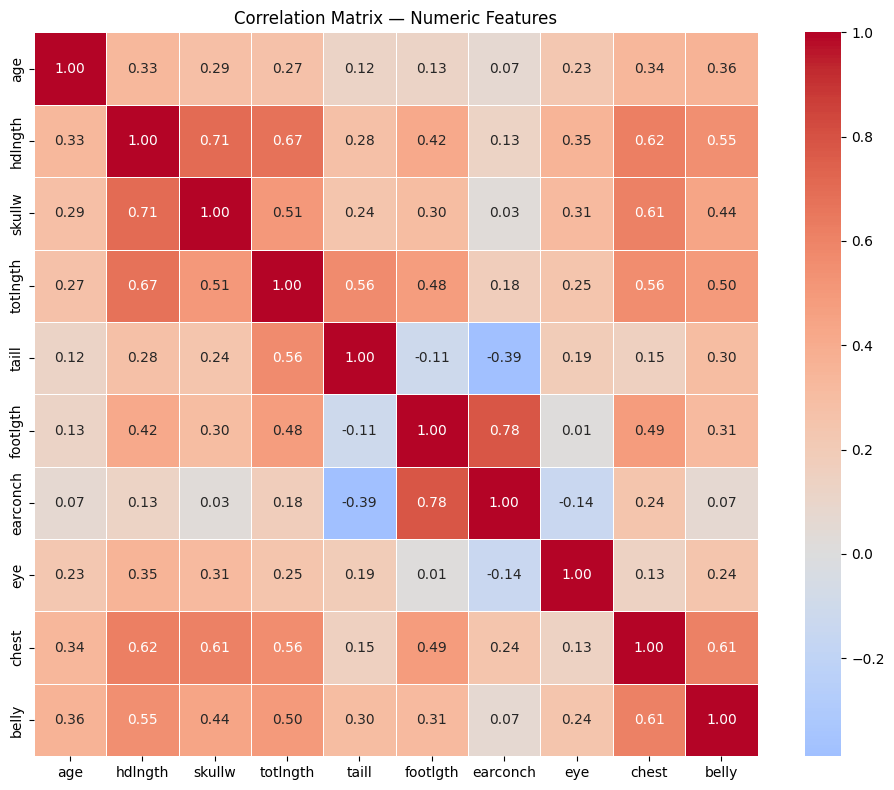


Feature correlations with age (sorted):
belly       0.361
chest       0.335
hdlngth     0.330
skullw      0.286
totlngth    0.268
eye         0.232
footlgth    0.126
taill       0.120
earconch    0.066
Name: age, dtype: float64


In [260]:
print("Correlation Heatmap (Numeric Features Only)")
print("-----------------")

numeric_df = df.drop(columns=["case", "site"]).select_dtypes(include="number")

plt.figure(figsize=(10, 8))
corr_matrix = numeric_df.corr()

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    square=True,
    linewidths=0.5
)
plt.title("Correlation Matrix — Numeric Features")
plt.tight_layout()
plt.show()

print("\nFeature correlations with age (sorted):")
print(corr_matrix["age"].drop("age").sort_values(ascending=False).round(3))

### Age vs. Numeric Scatter Plots

Scatter Plots: Age vs All Continuous Features
-----------------


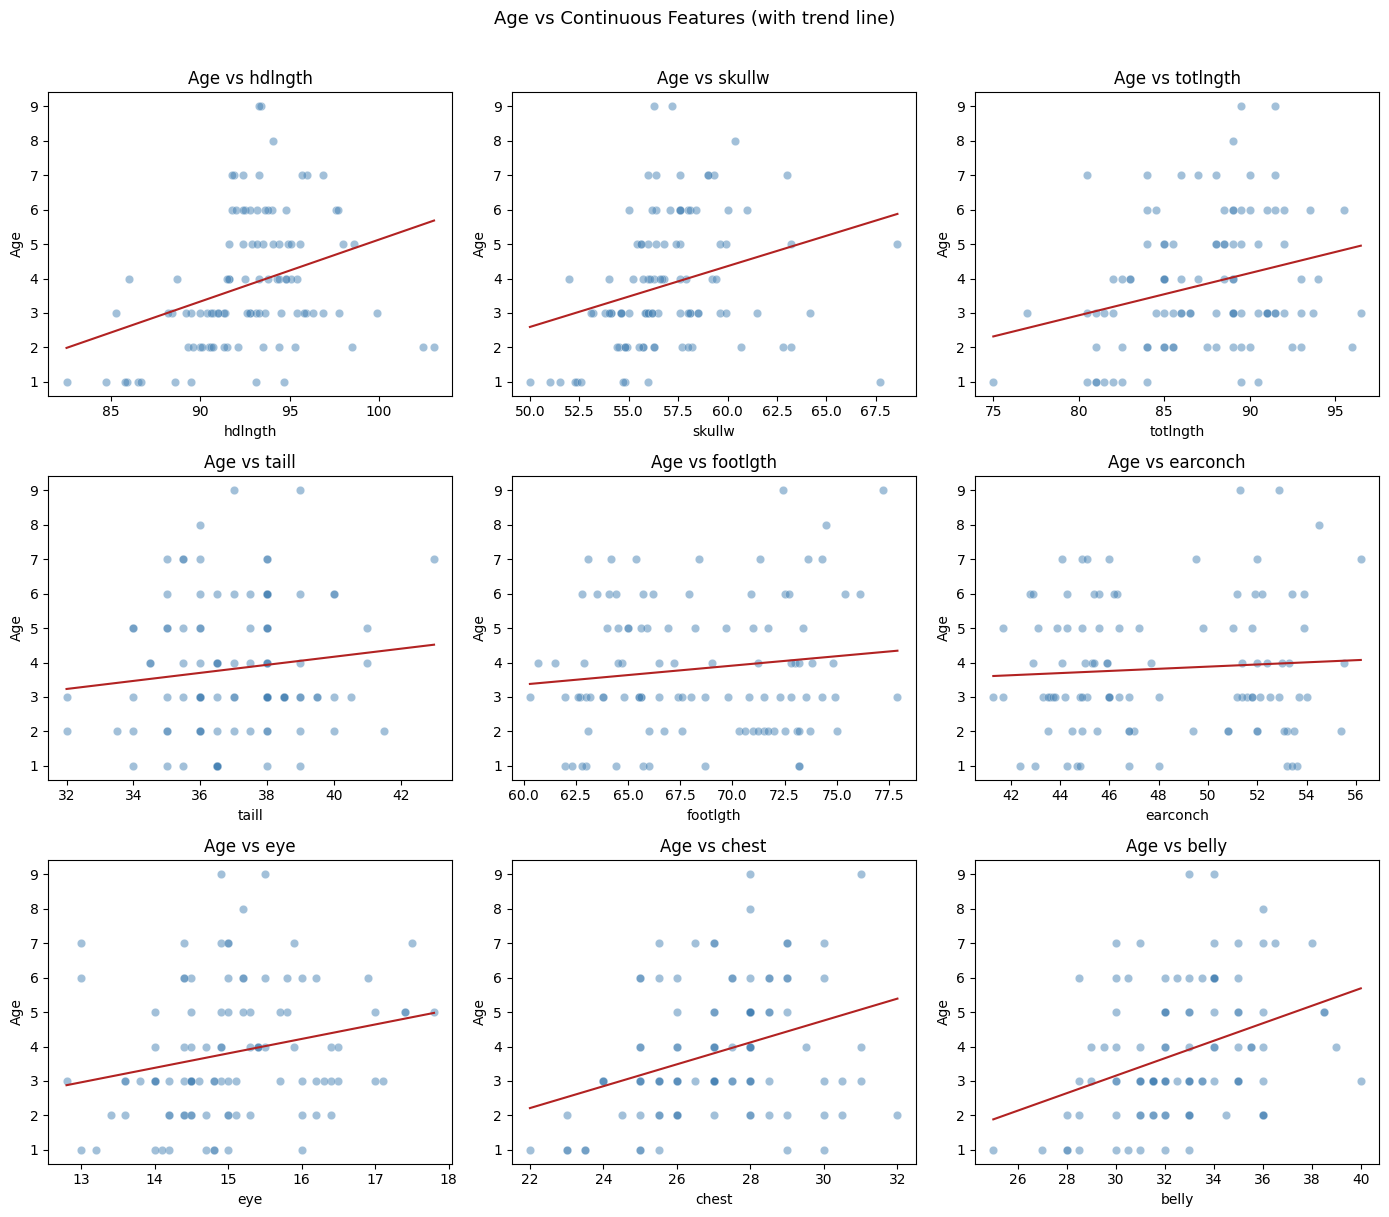

In [261]:
print("Scatter Plots: Age vs All Continuous Features")
print("-----------------")

continuous_features = ["hdlngth", "skullw", "totlngth", "taill", "footlgth", "earconch", "eye", "chest", "belly"]

fig, axes = plt.subplots(3, 3, figsize=(14, 12))
axes = axes.flatten()

for i, col in enumerate(continuous_features):
    temp = df[[col, "age"]].dropna()  # ← this line is the fix
    axes[i].scatter(temp[col], temp["age"], alpha=0.5, color="steelblue", edgecolors="white", linewidth=0.3)
    m, b = np.polyfit(temp[col], temp["age"], 1)
    x_line = np.linspace(temp[col].min(), temp[col].max(), 100)
    axes[i].plot(x_line, m * x_line + b, color="firebrick", linewidth=1.5)
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Age")
    axes[i].set_title(f"Age vs {col}")

plt.suptitle("Age vs Continuous Features (with trend line)", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

### Pairplot of Top Correlated Features

Pairplot of Top Correlated Features
-----------------


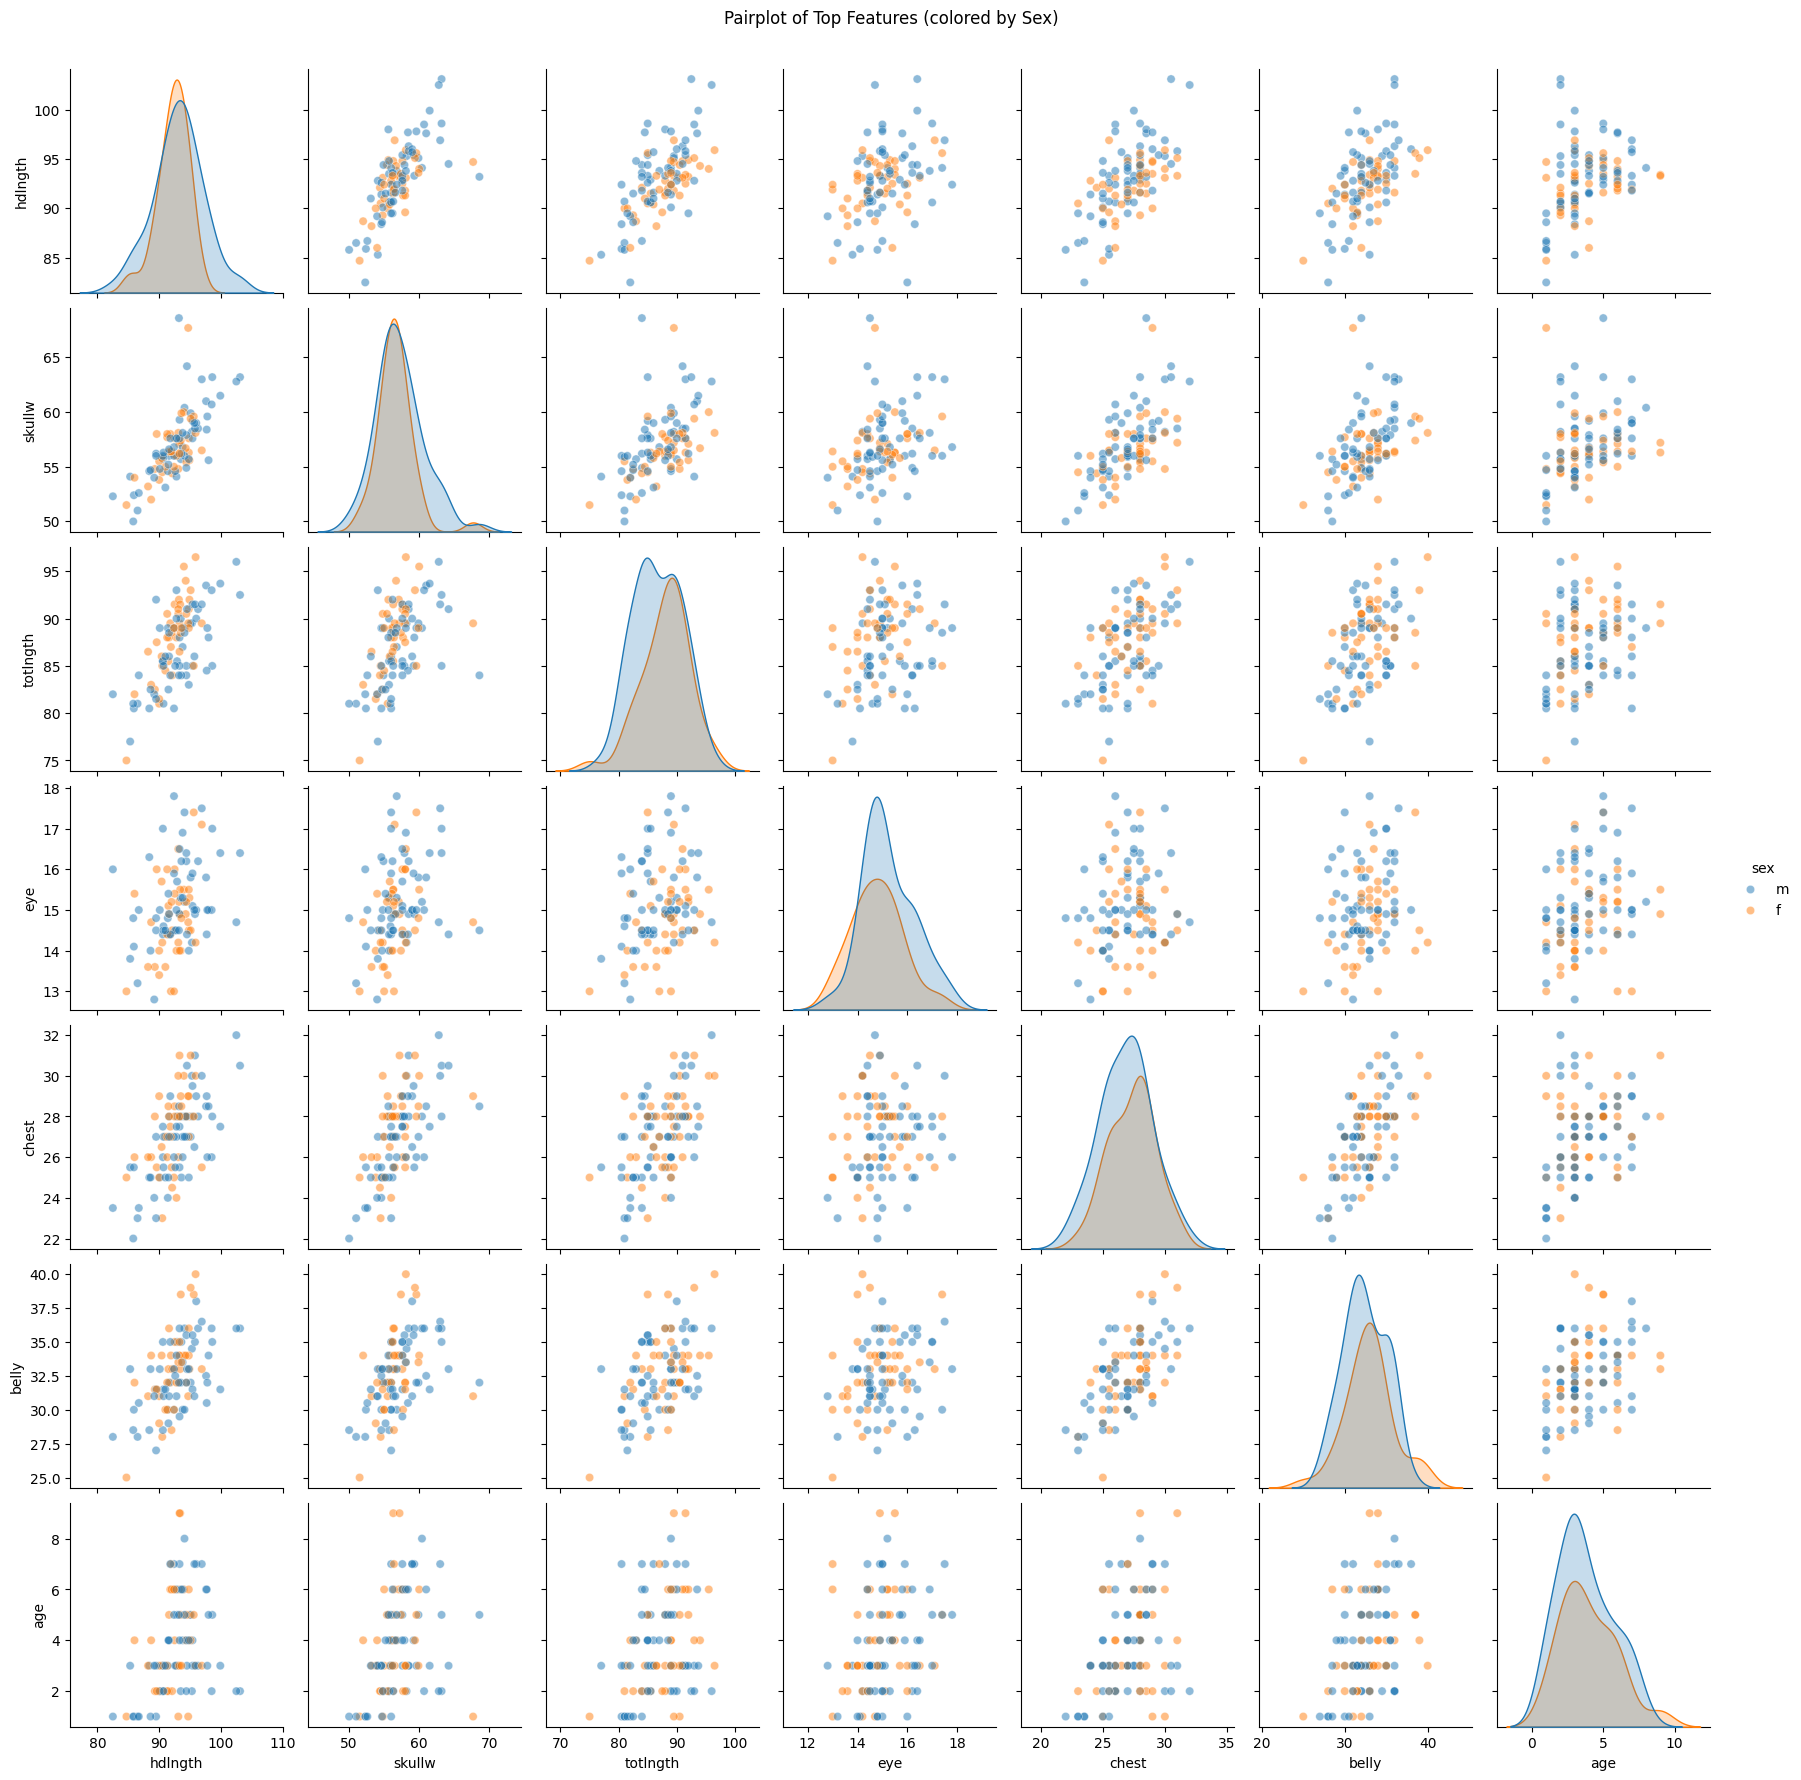

In [262]:
print("Pairplot of Top Correlated Features")
print("-----------------")

# Select features with abs correlation > 0.2 with age
top_features = corr_matrix["age"].drop("age").abs()
top_cols = top_features[top_features > 0.2].index.tolist()

sns.pairplot(df[top_cols + ["age", "sex"]], hue="sex", diag_kind="kde", plot_kws={"alpha": 0.5})
plt.suptitle("Pairplot of Top Features (colored by Sex)", y=1.02)
plt.show()

### Outlier Detection

Outlier Detection
-----------------


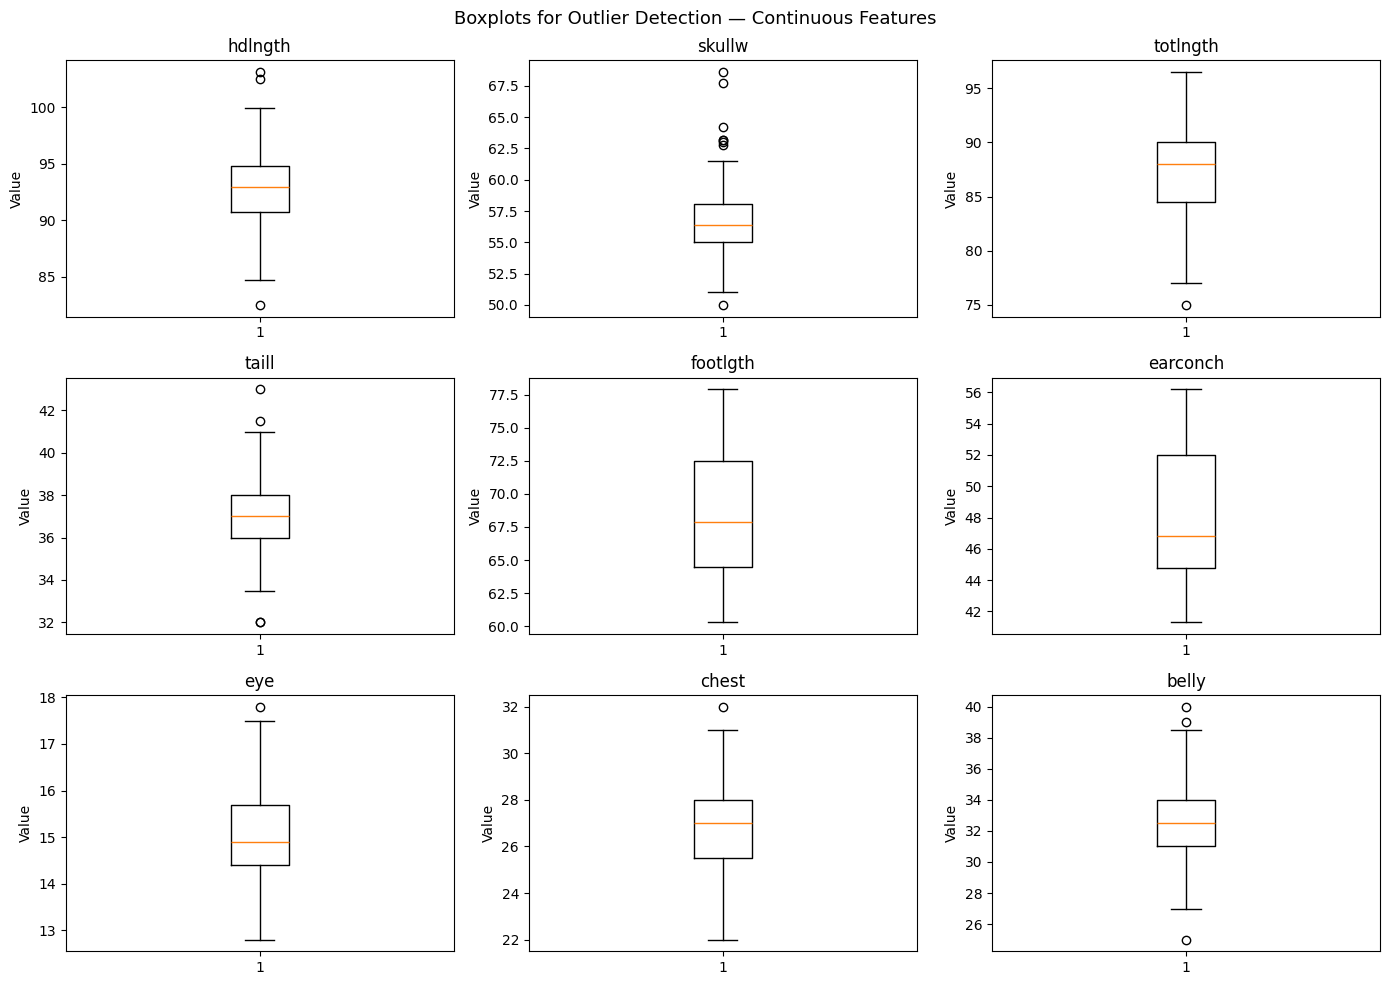

In [263]:
print("Outlier Detection")
print("-----------------")

fig, axes = plt.subplots(3, 3, figsize=(14, 10))
axes = axes.flatten()

for i, col in enumerate(continuous_features):
    axes[i].boxplot(df[col])
    axes[i].set_title(col)
    axes[i].set_ylabel("Value")

plt.suptitle("Boxplots for Outlier Detection — Continuous Features", fontsize=13)
plt.tight_layout()
plt.show()

### Summary

In [264]:
print("=== EDA Summary ===\n")
print(f"Observations after cleaning: {df.shape[0]}")
print(f"Features: {df.shape[1] - 1} predictors + 1 target (age)\n")

print("Sex breakdown:")
print(df["sex"].value_counts())

print("\nPopulation breakdown:")
print(df["Pop"].value_counts())

print("\nTop 3 features correlated with age:")
print(corr_matrix["age"].drop("age").abs().sort_values(ascending=False).head(3).round(3))

=== EDA Summary ===

Observations after cleaning: 101
Features: 13 predictors + 1 target (age)

Sex breakdown:
sex
m    59
f    42
Name: count, dtype: int64

Population breakdown:
Pop
other    58
Vic      43
Name: count, dtype: int64

Top 3 features correlated with age:
belly      0.361
chest      0.335
hdlngth    0.330
Name: age, dtype: float64


## Models

In [265]:
# imports!
import sklearn
from sklearn import base, metrics, linear_model
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder

### Preparation

In [266]:
X = df.drop(columns=["age"])
y = df["age"]

categorical_features = ["Pop", "sex", "site"]

numerical_features = [
    "hdlngth", "skullw", "totlngth", "taill",
    "footlgth", "earconch", "eye", "chest", "belly"
]

In [267]:
X_train, X_test, y_train, y_test = sklearn.model_selection.train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [268]:
def preprocessor(numeric, categorical):
  return ColumnTransformer(
      transformers=[
        ("num", numeric, numerical_features),
        ("cat", categorical, categorical_features)
      ]
    )

standardOneHot = preprocessor(
    StandardScaler(),
    OneHotEncoder(drop="first", handle_unknown="ignore")
    )

### Model Class

In [269]:
from sklearn.base import clone, RegressorMixin
from sklearn.preprocessing import PolynomialFeatures

models = {}

class Model:
  def __init__(self, preprocessor: ColumnTransformer, name: str, estimator: RegressorMixin, polynomials: bool):
    self.preprocessor = clone(preprocessor)
    self.name = name
    self.estimator = estimator
    self.model = self.__build(self.preprocessor, self.estimator, polynomials)

  def __build(self, preprocessor: ColumnTransformer, estimator: RegressorMixin, polynomials: bool):
    if polynomials:
      return Pipeline(steps=[
          ("preprocessor", preprocessor),
          ("polynomial", PolynomialFeatures(6, include_bias=False)),
          ("model", estimator)
      ])
    else:
      return Pipeline(steps=[
          ("preprocessor", preprocessor),
          ("model", estimator)
      ])

  def basics(self):
    self.fit()
    display(self.evaluate())
    self.summarize_coefficients()

  # Mutates self.model
  def fit(self, train_x=X_train, train_y=y_train):
    self.train = { "x": train_x, "y": train_y }
    self.model.fit(train_x, train_y)
    return self

  def predict(self, x, set_test=True):
    assert self.train is not None, "Must fit before predicting"
    y = self.model.predict(x)
    if set_test:
      self.set_test(x, y)
    return y

  def set_test(self, test_x, test_y):
    self.test = {"x": test_x, "y": test_y}

  def evaluate(self, test_x=X_test, test_y=y_test, set_test=True):
    if set_test:
      self.set_test(test_x, test_y)
    prediction = self.predict(test_x, set_test=False)
    return pd.DataFrame([{
        "Model": self.name,
        "MAE": metrics.mean_absolute_error(test_y, prediction),
        "RMSE": np.sqrt(metrics.mean_squared_error(test_y, prediction)),
        "R2": metrics.r2_score(test_y, prediction)
    }])

  def coefficients(self):
    feature_names = self.model.named_steps["preprocessor"].get_feature_names_out()
    coefficients = self.model.named_steps["model"].coef_

    coef_df = pd.DataFrame({
        "Feature": feature_names,
        "Coefficient": coefficients
    })

    coef_df["Abs_Coefficient"] = coef_df["Coefficient"].abs()
    return coef_df.sort_values("Abs_Coefficient", ascending=False)

  def zero_coefficients(self, coefficients=None):
    if coefficients is None:
      coefficients = self.coefficients()
    return coefficients[coefficients["Coefficient"] == 0]

  def summarize_coefficients(self):
    coefficients = self.coefficients()
    display(coefficients.head())

    zero_coefficients = self.zero_coefficients(coefficients)
    print("Eliminated Coefficients:", len(zero_coefficients))
    display(zero_coefficients[["Feature", "Coefficient"]])

### Multiple Linear Regression

In [270]:
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

class MultipleLinearRegression(Model):
  def __init__(self, polynomials: bool, preprocessor=standardOneHot):
    estimator = LinearRegression()
    super().__init__(
        name="Multiple Linear Regression",
        estimator=estimator,
        preprocessor=preprocessor,
        polynomials=polynomials
        )

  def actual_predicted_scatterplot(self, test_x=None, test_y=None, set_test=False):
    self.__plot(test_x, test_y, set_test, MultipleLinearRegression.__actual_predicted_scatterplot)

  def residuals_scatterplot(self, test_x=None, test_y=None, set_test=False):
    self.__plot(test_x, test_y, set_test, MultipleLinearRegression.__residuals_scatterplot)

  def __plot(self, test_x, test_y, set_test, f):
    if test_x is None or test_y is None:
      assert self.test != None, "Can only plot with test data"
      test_x, test_y, set_test = (self.test['x'], self.test['y'], False)
    pred_y = self.predict(test_x, set_test=set_test)
    f(test_y, pred_y)

  def __actual_predicted_scatterplot(test_y, pred_y):
    plt.figure(figsize=(6, 6))
    plt.scatter(test_y, pred_y) # *

    plt.xlabel("Actual Age")
    plt.ylabel("Predicted Age")
    plt.title("Actual vs Predicted Age: Multiple Linear Regression")

    min_age = min(test_y.min(), pred_y.min())
    max_age = max(test_y.max(), pred_y.max())

    plt.plot([min_age, max_age], [min_age, max_age])

    plt.show()

  def __residuals_scatterplot(test_y, pred_y):
    residuals = test_y - pred_y

    plt.figure(figsize=(6, 4))
    plt.scatter(pred_y, residuals)
    plt.axhline(0)

    plt.xlabel("Predicted Age")
    plt.ylabel("Residuals")
    plt.title("Residual Plot")

    plt.show()

In [271]:
linear_model = models["MultipleLinearRegression"] = MultipleLinearRegression(False)
linear_model.basics()

,Model,MAE,RMSE,R2
0,Multiple Linear Regression,1.549344,2.093992,0.030242


,Feature,Coefficient,Abs_Coefficient
9,cat__Pop_other,-2.096304,2.096304
13,cat__site_4,-1.552706,1.552706
4,num__footlgth,-1.168908,1.168908
11,cat__site_2,0.733167,0.733167
12,cat__site_3,-0.509169,0.509169


Eliminated Coefficients: 0


,Feature,Coefficient


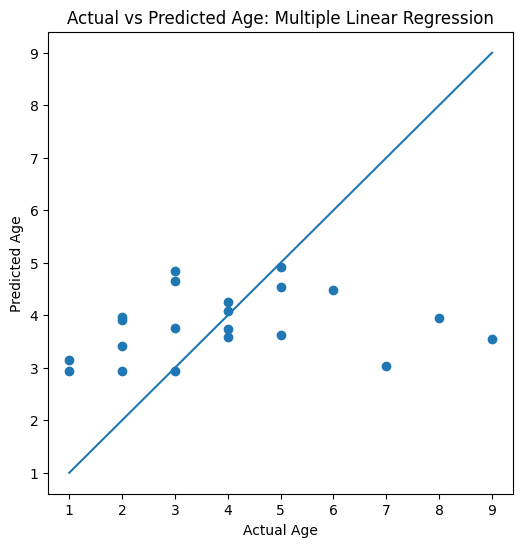

In [272]:
linear_model.actual_predicted_scatterplot()

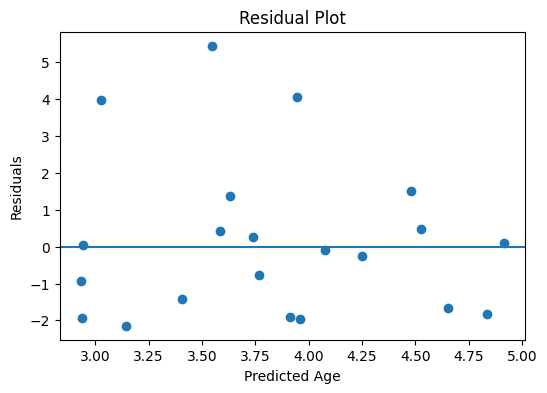

In [273]:
linear_model.residuals_scatterplot()

### LASSO

In [274]:
from sklearn.linear_model import Lasso

class LASSO(Model):
  def __init__(self, polynomials: bool, alpha=0.05):
    super().__init__(
        name="Lasso Regression",
        estimator=Lasso(alpha=alpha, max_iter=10000, random_state=42),
        preprocessor=standardOneHot,
        polynomials=polynomials
    )

In [275]:
lasso_model = models["LASSO"] = LASSO(False)
lasso_model.basics()

,Model,MAE,RMSE,R2
0,Lasso Regression,1.513747,1.995883,0.118984


,Feature,Coefficient,Abs_Coefficient
13,cat__site_4,-0.620651,0.620651
4,num__footlgth,-0.325732,0.325732
8,num__belly,0.323065,0.323065
6,num__eye,0.309662,0.309662
0,num__hdlngth,0.252179,0.252179


Eliminated Coefficients: 8


,Feature,Coefficient
3,num__taill,0.0
9,cat__Pop_other,-0.0
11,cat__site_2,0.0
10,cat__sex_m,-0.0
12,cat__site_3,-0.0
14,cat__site_5,-0.0
15,cat__site_6,0.0
16,cat__site_7,0.0


### Cross-Validated LASSO

#### Old from Max

In [276]:
from sklearn.linear_model import LassoCV

class OldCVLasso(Model):
  def __init__(self, polynomials: bool):
    super().__init__(
        name = "LassoCV Regression",
        estimator = LassoCV(
          alphas=[0.001, 0.01, 0.05, 0.1, 0.5, 1.0],
          cv=5,
          max_iter=10000,
          random_state=42
        ),
        preprocessor = standardOneHot,
        polynomials=polynomials
    )

  def best_alpha(self):
    return self.model.named_steps["model"].alpha_

In [277]:
lasso_cv_model = models["OldCVLasso"] = OldCVLasso(False)
lasso_cv_model.basics()
print("Best alpha:", lasso_cv_model.best_alpha())

,Model,MAE,RMSE,R2
0,LassoCV Regression,1.676786,2.132775,-0.006012


,Feature,Coefficient,Abs_Coefficient
0,num__hdlngth,0.0,0.0
1,num__skullw,0.0,0.0
2,num__totlngth,0.0,0.0
3,num__taill,0.0,0.0
4,num__footlgth,0.0,0.0


Eliminated Coefficients: 17


,Feature,Coefficient
0,num__hdlngth,0.0
1,num__skullw,0.0
2,num__totlngth,0.0
3,num__taill,0.0
4,num__footlgth,0.0
5,num__earconch,0.0
6,num__eye,0.0
7,num__chest,0.0
8,num__belly,0.0
9,cat__Pop_other,-0.0


Best alpha: 1.0


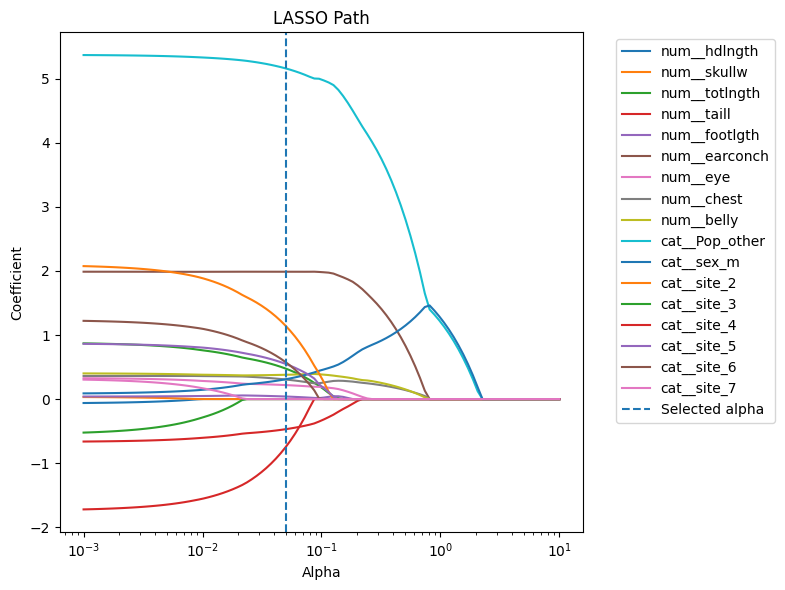

In [278]:
from sklearn.linear_model import lasso_path

preprocessor_fitted = lasso_model.model.named_steps["preprocessor"]
X_train_processed = preprocessor_fitted.transform(X_train)

if hasattr(X_train_processed, "toarray"):
    X_train_processed = X_train_processed.toarray()

feature_names = preprocessor_fitted.get_feature_names_out()

alphas = np.logspace(-3, 1, 100)
alphas_lasso, coefs_lasso, _ = lasso_path(
    X_train_processed,
    y_train,
    alphas=alphas
)

plt.figure(figsize=(8, 6))

for i in range(coefs_lasso.shape[0]):
    plt.plot(alphas_lasso, coefs_lasso[i], label=feature_names[i])

plt.xscale("log")
plt.axvline(
    lasso_model.model.named_steps["model"].alpha,
    linestyle="--",
    label="Selected alpha"
)

plt.xlabel("Alpha")
plt.ylabel("Coefficient")
plt.title("LASSO Path")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

#### New from Ben

Based on [Step 5](https://colab.research.google.com/drive/1IZp9rhVqjTqA345U5FHREb_a3kLWE4ZB#scrollTo=3_45f4euhnWw) of InterWeek5.ipynb

This is a bit spaghetti code and should have been made to meld with `Model`. But I don't have time!

The most impactful change here was setting `cv=10`. I have no idea why.

In [279]:
from sklearn.model_selection import GridSearchCV
import matplotlib.pyplot as plt

class CVLasso:
  def __init__(self, polynomials: bool):
    self.name = "Grid-Search CV Lasso"
    self.preprocessor = standardOneHot
    self.estimator = Lasso(random_state=42, max_iter=10000)
    if polynomials:
      self.model = Pipeline(steps=[
          ("preprocessor", self.preprocessor),
          ("polynomial", PolynomialFeatures(6, include_bias=False)),
          ("lasso", self.estimator)
      ])
    else:
      self.model = Pipeline(steps=[
          ("preprocessor", self.preprocessor),
          ("lasso", self.estimator)
      ])
    param_grid = {'lasso__alpha': np.logspace(-4, 4, 100)}
    self.grid = GridSearchCV(self.model,
                             param_grid,
                             cv=10,
                             scoring='neg_mean_squared_error',
                             n_jobs=-1)

  def set_test(self, test_x, test_y):
    self.test = {"x": test_x, "y": test_y}

  def basics(self):
    self.fit()
    display(self.evaluate())
    self.summarize_coefficients()

  def fit(self, train_x=X_train, train_y=y_train):
    self.train = { "x": train_x, "y": train_y }
    self.grid.fit(train_x, train_y)
    return self

  def best_alpha(self):
    assert self.train is not None, "Must fit before getting best alpha"
    return self.grid.best_params_['lasso__alpha']

  def evaluate(self, test_x=X_test, test_y=y_test, set_test=True):
    if set_test:
      self.set_test(test_x, test_y)

    prediction = self.grid.predict(test_x)
    return pd.DataFrame([{
        "Model": self.name,
        "MAE": metrics.mean_absolute_error(test_y, prediction),
        "RMSE": np.sqrt(metrics.mean_squared_error(test_y, prediction)),
        "R2": metrics.r2_score(test_y, prediction)
    }])

  def coefficients_regularization_plot(self, train_x=None, train_y=None):
    if train_x is None or train_y is None:
      if self.train is not None:
        train_x, train_y = (self.train['x'], self.train['y'])
      else:
        train_x, train_y = (X_train, y_train)
    # Prepare a range of alpha values for LASSO
    alphas = np.logspace(-4, 4, 100)

    # Initialize an empty array to store the coefficients for each alpha
    coefs = []

    # Fit the LASSO model for each alpha and store the coefficients
    for alpha in alphas:
        pipeline = Pipeline(steps=[
          ("preprocessor", self.preprocessor),
          ("lasso", self.estimator.set_params(alpha=alpha))
        ])
        pipeline.fit(train_x, train_y)
        coefs.append(pipeline.named_steps['lasso'].coef_)

    # Plot the parameter estimates against alpha values
    plt.figure(figsize=(6, 4))
    ax = plt.gca()
    ax.plot(alphas, coefs)
    ax.set_xscale('log')
    plt.xlabel('Alpha (log scale)')
    plt.ylabel('Parameter estimates')
    plt.title('LASSO coefficients as a function of the regularization')
    plt.legend(X.columns, loc='upper right')
    plt.show()

  def mse_regularization(self, test_x=None, test_y=None):
    assert self.train is not None, "Must fit before plotting"

    if test_x is None or test_y is None:
      assert self.test != None, "Can only plot with test data"
      test_x, test_y = (self.test['x'], self.test['y'])

    train_x, train_y = (self.train['x'], self.train['y'])

    # Prepare a range of alpha values for LASSO
    alphas = np.logspace(-4, 4, 100)

    # Initialize an empty array to store the mean squared errors for each alpha
    mse = []

    # Fit the LASSO model for each alpha and store the mean squared error
    for alpha in alphas:
        pipeline = Pipeline(steps=[
          ("preprocessor", self.preprocessor),
          ("lasso", self.estimator.set_params(alpha=alpha))
        ])
        pipeline.fit(train_x, train_y)
        pred_y = pipeline.predict(test_x)
        mse.append(metrics.mean_squared_error(test_y, pred_y))

    # Plot the mean squared errors against alpha values
    plt.figure(figsize=(6, 4))
    plt.plot(alphas, mse, label='Mean Squared Error')
    # add a vertical line to mark the best alpha
    plt.axvline(x=self.best_alpha(), color='red', linestyle='--', label='Best alpha')
    plt.xscale('log')
    plt.xlabel('Alpha (log scale)')
    plt.ylabel('Mean Squared Error')
    plt.title('MSE as a function of the regularization (LASSO)')
    plt.legend()
    plt.show();

  def coefficients(self):
    feature_names = self.grid.best_estimator_.named_steps["preprocessor"].get_feature_names_out()
    coefficients = self.grid.best_estimator_.named_steps["lasso"].coef_

    coef_df = pd.DataFrame({
        "Feature": feature_names,
        "Coefficient": coefficients
    })

    coef_df["Abs_Coefficient"] = coef_df["Coefficient"].abs()
    return coef_df.sort_values("Abs_Coefficient", ascending=False)

  def zero_coefficients(self, coefficients=None):
    if coefficients is None:
      coefficients = self.coefficients()
    return coefficients[coefficients["Coefficient"] == 0]

  def summarize_coefficients(self):
    coefficients = self.coefficients()
    display(coefficients.head())

    zero_coefficients = self.zero_coefficients(coefficients)
    print("Eliminated Coefficients:", len(zero_coefficients))
    display(zero_coefficients[["Feature", "Coefficient"]])

In [280]:
cv_model = models["CVLasso"] = CVLasso(False)
cv_model.basics()

,Model,MAE,RMSE,R2
0,Grid-Search CV Lasso,1.52433,2.008127,0.108142


,Feature,Coefficient,Abs_Coefficient
8,num__belly,0.266482,0.266482
6,num__eye,0.225286,0.225286
0,num__hdlngth,0.176655,0.176655
7,num__chest,0.096680,0.096680
1,num__skullw,0.000000,0.000000


Eliminated Coefficients: 13


,Feature,Coefficient
1,num__skullw,0.0
4,num__footlgth,-0.0
3,num__taill,0.0
2,num__totlngth,0.0
5,num__earconch,0.0
9,cat__Pop_other,-0.0
10,cat__sex_m,-0.0
11,cat__site_2,0.0
12,cat__site_3,-0.0
13,cat__site_4,-0.0


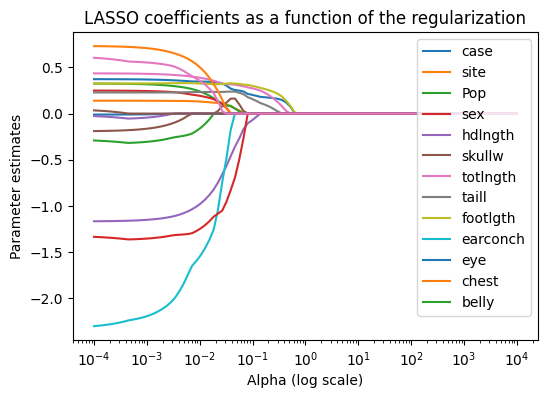

In [281]:
cv_model.coefficients_regularization_plot()

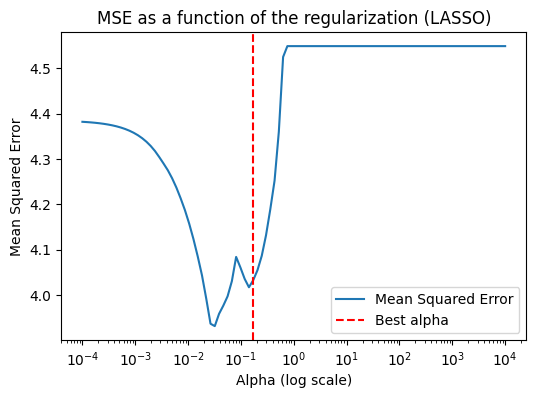

In [282]:
cv_model.mse_regularization()

### Polynomials

,Model,MAE,RMSE,R2
0,Multiple Linear Regression,3.531171,5.778404,-6.384639


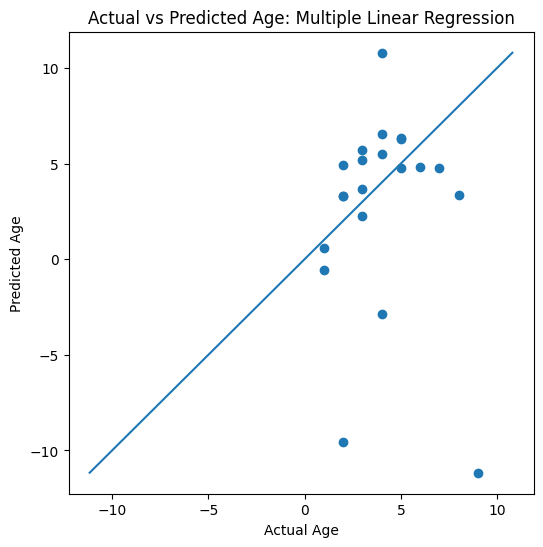

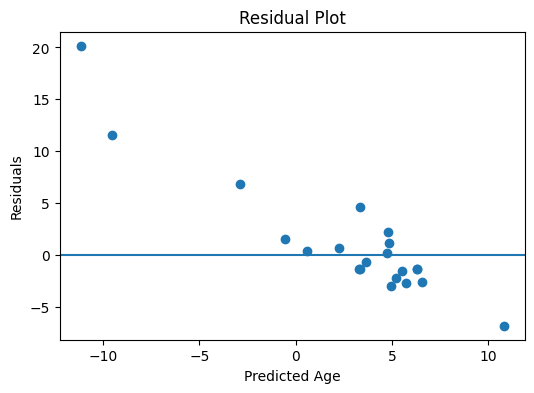

In [283]:
linear_poly = MultipleLinearRegression(True)
linear_poly.fit()
display(linear_poly.evaluate())
linear_poly.actual_predicted_scatterplot()
linear_poly.residuals_scatterplot()

In [284]:
lasso_poly = LASSO(True)
lasso_poly.fit()
display(lasso_poly.evaluate())

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 5.955e+00, tolerance: 2.714e-02
  model = cd_fast.enet_coordinate_descent(


,Model,MAE,RMSE,R2
0,Lasso Regression,3.138671,4.442775,-3.36538


In [285]:
# lasso_cv_poly = CVLasso(True)
# lasso_cv_poly.fit()
# display(lasso_cv_poly.evaluate())
# lasso_cv_poly.coefficients_regularization_plot()
# lasso_cv_poly.mse_regularization()

## Comparison

In [286]:
import kagglehub
from kagglehub import KaggleDatasetAdapter

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.base import clone

from sklearn.linear_model import LinearRegression, Lasso, LassoCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [287]:
linear_results = linear_model.evaluate()
lasso_results = lasso_model.evaluate()
lasso_cv_results = lasso_cv_model.evaluate()

model_comparison = pd.concat([linear_results, lasso_results, lasso_cv_results])

model_comparison

,Model,MAE,RMSE,R2
0,Multiple Linear Regression,1.549344,2.093992,0.030242
0,Lasso Regression,1.513747,1.995883,0.118984
0,LassoCV Regression,1.676786,2.132775,-0.006012


Among the three models, ordinary Lasso Regression performed the best. It had the lowest MAE and RMSE, and the highest R². Compared with Multiple Linear Regression, Lasso reduced the average prediction error and explained more variation in possum age. In contrast, LassoCV performed worse than both models, with a higher MAE and RMSE and a negative R² value.

Therefore, based on the test set results, **ordinary Lasso Regression** was the best-performing model.

Although LassoCV is more systematic because it selects the alpha value through cross-validation, it did not perform well on this test set. This may be due to the small sample size and the sensitivity of the train-test split.

Note from Ben: LassoCV is cross-validated LASSO. So, our particular `lasso_model` should be a within the grand sapce of LassoCV. This makes me think that something is up with the `lasso_cv_model`.

### Standardized Heatmap

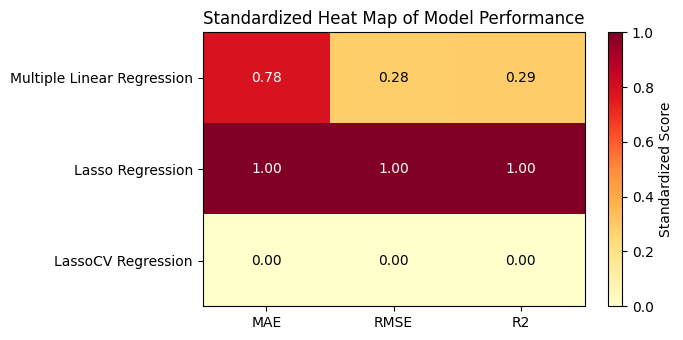

In [288]:
heatmap_df = model_comparison.set_index("Model")

standardized_heatmap = pd.DataFrame(index=heatmap_df.index)

for metric in heatmap_df.columns:
    values = heatmap_df[metric]
    value_range = values.max() - values.min()

    if value_range == 0:
        standardized_heatmap[metric] = 1
    elif metric in ["MAE", "RMSE"]:
        standardized_heatmap[metric] = (values.max() - values) / value_range
    else:
        standardized_heatmap[metric] = (values - values.min()) / value_range

data = standardized_heatmap.values

plt.figure(figsize=(7, 3.5))

plt.imshow(data, aspect="auto", cmap="YlOrRd", vmin=0, vmax=1)

plt.xticks(
    np.arange(len(standardized_heatmap.columns)),
    standardized_heatmap.columns
)
plt.yticks(
    np.arange(len(standardized_heatmap.index)),
    standardized_heatmap.index
)

for i in range(data.shape[0]):
    for j in range(data.shape[1]):
        text_color = "white" if data[i, j] > 0.55 else "black"
        plt.text(
            j,
            i,
            f"{data[i, j]:.2f}",
            ha="center",
            va="center",
            color=text_color
        )

plt.title("Standardized Heat Map of Model Performance")
plt.colorbar(label="Standardized Score")
plt.tight_layout()
plt.show()

The standardized heat map compares the performance of the three models across MAE, RMSE, and R². A higher standardized score means better performance.

**Lasso Regression** performs the **best** overall, with a score of 1.00 for all three metrics.

**Multiple Linear Regression** has **moderate** performance, especially for MAE, but its RMSE and R² scores are much lower.

**LassoCV Regression** performs the **worst** in this comparison, with the lowest standardized scores across all metrics.

## Further work(EDA)

### correlation heat map

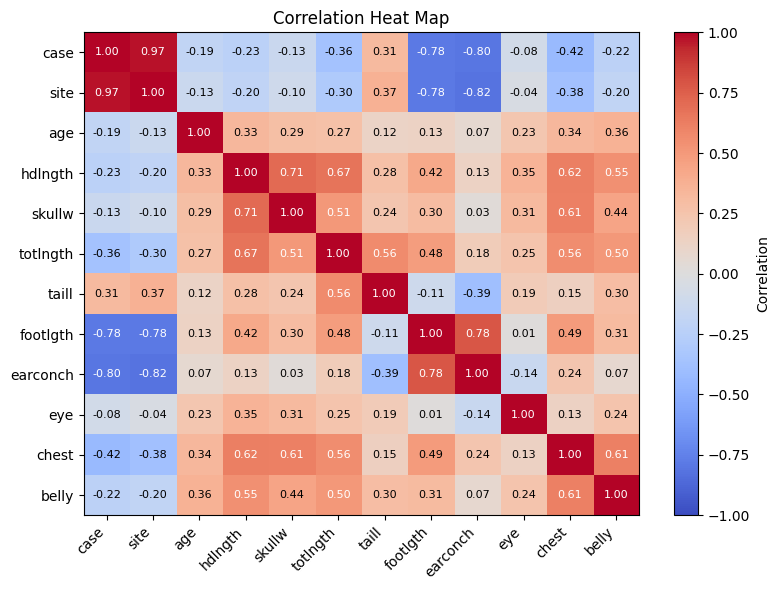

In [289]:
corr_df = df.select_dtypes(include=["int64", "float64"]).corr()
data = corr_df.values

plt.figure(figsize=(8, 6))
plt.imshow(data, aspect="auto", vmin=-1, vmax=1, cmap="coolwarm")

plt.xticks(np.arange(len(corr_df.columns)), corr_df.columns, rotation=45, ha="right")
plt.yticks(np.arange(len(corr_df.index)), corr_df.index)

for i in range(data.shape[0]):
    for j in range(data.shape[1]):
        text_color = "white" if abs(data[i, j]) > 0.5 else "black"
        plt.text(
            j,
            i,
            f"{data[i, j]:.2f}",
            ha="center",
            va="center",
            color=text_color,
            fontsize=8
        )

plt.title("Correlation Heat Map")
plt.colorbar(label="Correlation")
plt.tight_layout()
plt.show()

## Random Forest Regression

### Helper Functions



In [290]:
# Standardize scalar/numeric values: adjust to a normal distribution
# x' = (x - mean) / std_dev
# Center aroud 0 (x - mean) and scale (/ std_dev)
# Assumes normality
numeric_transformer = Pipeline(steps=[
    ("scaler", StandardScaler())
])

# One-hot: categorical data encoded as a boolean (1/0) array
# e.g. 'm' : [ 1, 0 ]
#      'f' : [ 0, 1 ]
categorical_transformer = Pipeline(steps=[
    ("onehot", OneHotEncoder(drop="first", handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numerical_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

In [291]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

def build_model(estimator) -> Pipeline:
    return Pipeline(steps=[
        ("preprocessor", clone(preprocessor)),
        ("model", estimator)
    ])


def evaluate_predictions(y_true: list[float],
                         y_pred: list[float],
                         model_name: str):
    return {
        "Model": model_name,
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
        "R2": r2_score(y_true, y_pred)
    }

# Get DataFrame of Feature names, associated Coefficient, and Absolute value of that coefficient
# sorted by descending Abs_Coefficient
def get_coefficient_table(model: Pipeline):
    feature_names = model.named_steps["preprocessor"].get_feature_names_out()
    coefficients = model.named_steps["model"].coef_

    coef_df = pd.DataFrame({
        "Feature": feature_names,
        "Coefficient": coefficients
    })

    coef_df["Abs_Coefficient"] = coef_df["Coefficient"].abs()
    return coef_df.sort_values("Abs_Coefficient", ascending=False)

### Build and Fit

In [292]:
from sklearn.ensemble import RandomForestRegressor

random_forest_model = build_model(
    RandomForestRegressor(
        n_estimators=300,
        max_depth=4,
        min_samples_leaf=3,
        random_state=42
    )
)

random_forest_model.fit(X_train, y_train);

### Assessment

In [293]:
y_pred_random_forest = random_forest_model.predict(X_test)

random_forest_results = evaluate_predictions(
    y_test,
    y_pred_random_forest,
    "Random Forest Regression"
)

pd.DataFrame([random_forest_results])

,Model,MAE,RMSE,R2
0,Random Forest Regression,1.332157,1.715237,0.349328


### Comparison

In [294]:
y_pred_linear = linear_model.predict(X_test)
y_pred_lasso = lasso_model.predict(X_test)
y_pred_lasso_cv = lasso_cv_model.predict(X_test)
y_pred_random_forest = random_forest_model.predict(X_test)

linear_results = evaluate_predictions(
    y_test,
    y_pred_linear,
    "Multiple Linear Regression"
)

lasso_results = evaluate_predictions(
    y_test,
    y_pred_lasso,
    "Lasso Regression"
)

lasso_cv_results = evaluate_predictions(
    y_test,
    y_pred_lasso_cv,
    "LassoCV Regression"
)

random_forest_results = evaluate_predictions(
    y_test,
    y_pred_random_forest,
    "Random Forest Regression"
)

model_comparison = pd.DataFrame([
    linear_results,
    lasso_results,
    lasso_cv_results,
    random_forest_results
])

model_comparison

,Model,MAE,RMSE,R2
0,Multiple Linear Regression,1.549344,2.093992,0.030242
1,Lasso Regression,1.513747,1.995883,0.118984
2,LassoCV Regression,1.676786,2.132775,-0.006012
3,Random Forest Regression,1.332157,1.715237,0.349328


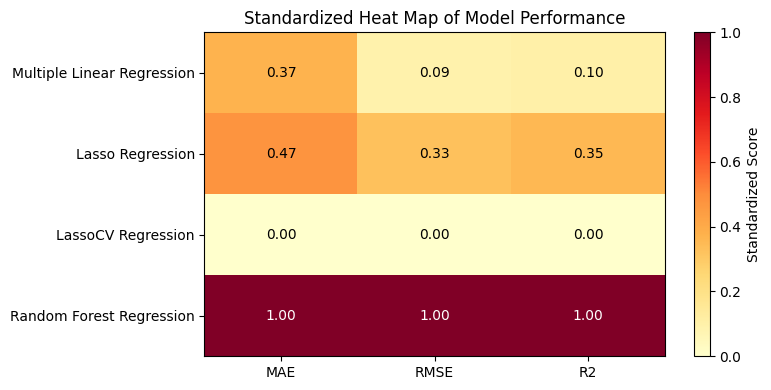

In [295]:
heatmap_df = model_comparison.set_index("Model")

standardized_heatmap = pd.DataFrame(index=heatmap_df.index)

for metric in heatmap_df.columns:
    values = heatmap_df[metric]
    value_range = values.max() - values.min()

    if value_range == 0:
        standardized_heatmap[metric] = 1
    elif metric in ["MAE", "RMSE"]:
        standardized_heatmap[metric] = (values.max() - values) / value_range
    else:
        standardized_heatmap[metric] = (values - values.min()) / value_range

data = standardized_heatmap.values

plt.figure(figsize=(8, 4))

plt.imshow(data, aspect="auto", cmap="YlOrRd", vmin=0, vmax=1)

plt.xticks(
    np.arange(len(standardized_heatmap.columns)),
    standardized_heatmap.columns
)

plt.yticks(
    np.arange(len(standardized_heatmap.index)),
    standardized_heatmap.index
)

for i in range(data.shape[0]):
    for j in range(data.shape[1]):
        text_color = "white" if data[i, j] > 0.55 else "black"
        plt.text(
            j,
            i,
            f"{data[i, j]:.2f}",
            ha="center",
            va="center",
            color=text_color
        )

plt.title("Standardized Heat Map of Model Performance")
plt.colorbar(label="Standardized Score")
plt.tight_layout()
plt.show()

The standardized heat map shows that **Random Forest Regression** performs the **best** among the four models. It has the highest standardized score of 1.00 for MAE, RMSE, and R², which means it has the lowest prediction errors and the highest explanatory power in this comparison. Lasso Regression performs better than Multiple Linear Regression overall, especially for RMSE and R². Multiple Linear Regression has weaker performance, while LassoCV Regression performs the worst across all three metrics.

### Scatter Plot

In [296]:
y_pred_lasso_all = lasso_model.predict(X)
y_pred_random_forest_all = random_forest_model.predict(X)

residuals_lasso_all = y - y_pred_lasso_all
residuals_random_forest_all = y - y_pred_random_forest_all

#### Actual vs. Predicted Age

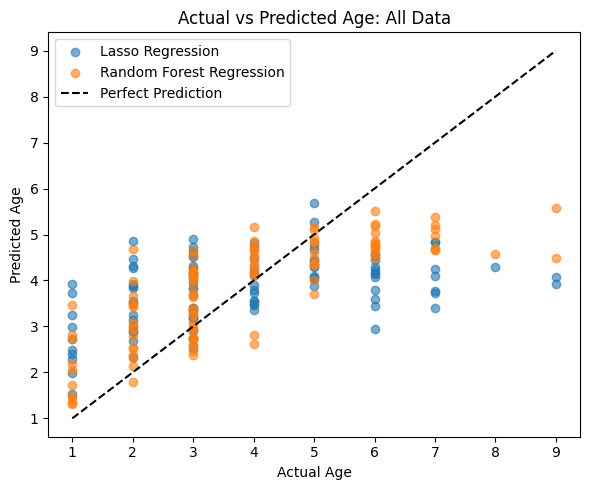

In [297]:
min_age = min(y.min(), y_pred_lasso_all.min(), y_pred_random_forest_all.min())
max_age = max(y.max(), y_pred_lasso_all.max(), y_pred_random_forest_all.max())

plt.figure(figsize=(6, 5))

plt.scatter(
    y,
    y_pred_lasso_all,
    label="Lasso Regression",
    alpha=0.6
)

plt.scatter(
    y,
    y_pred_random_forest_all,
    label="Random Forest Regression",
    alpha=0.6
)

plt.plot(
    [min_age, max_age],
    [min_age, max_age],
    linestyle="--",
    color="black",
    label="Perfect Prediction"
)

plt.xlabel("Actual Age")
plt.ylabel("Predicted Age")
plt.title("Actual vs Predicted Age: All Data")
plt.legend()
plt.tight_layout()
plt.show()

#### Residuals

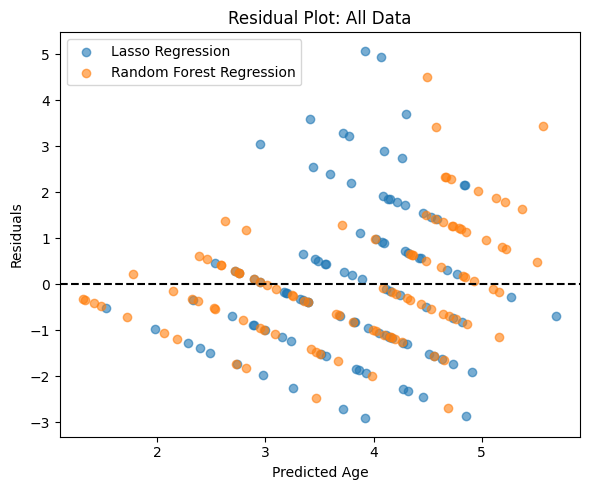

In [298]:
plt.figure(figsize=(6, 5))

plt.scatter(
    y_pred_lasso_all,
    residuals_lasso_all,
    label="Lasso Regression",
    alpha=0.6
)

plt.scatter(
    y_pred_random_forest_all,
    residuals_random_forest_all,
    label="Random Forest Regression",
    alpha=0.6
)

plt.axhline(
    y=0,
    linestyle="--",
    color="black"
)

plt.xlabel("Predicted Age")
plt.ylabel("Residuals")
plt.title("Residual Plot: All Data")
plt.legend()
plt.tight_layout()
plt.show()

## Summary of the Modeling Process

After cleaning the raw data, I obtained the final dataset for analysis. I first built a **multiple linear regression model**, but the results were only moderate. The model did not fit the data particularly well, suggesting that a simple linear approach might not fully capture the patterns in the dataset.

To improve the model performance, I then applied **Lasso regression**. Compared with the multiple linear regression model, Lasso performed slightly better. This suggests that regularization helped reduce noise and improve the model to some extent.

Next, I tried to further improve the result by using **LassoCV**, which automatically selects the best alpha value through cross-validation. However, the alpha selected by LassoCV was too strong, causing all coefficients to shrink to zero. As a result, the model removed all useful predictors and could not be effectively used.

Overall, among the regression-based models, **Lasso regression produced the best result**, although its performance was still limited.

As part of the **exploratory data analysis (EDA)**, I also created a **correlation heat map** to better understand the relationships between variables. The heat map suggested that the data might contain more complex and non-linear patterns, which may not be well captured by linear regression models. Therefore, I decided to try a **Random Forest model**.

**The Random Forest model achieved the best performance** among all the models. This indicates that it was more suitable for this dataset, especially because it can capture non-linear relationships and interactions between variables more effectively than linear models.

In conclusion, although Lasso regression improved the results compared with multiple linear regression, the overall performance of linear models remained limited. The Random Forest model provided the best result and appeared to be the most appropriate model for this dataset.